In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Overview and Preprocessing

## Data Overview

In [ ]:
# Read and view dataset
df = pd.read_csv("/content/drive/MyDrive/AI - ShlokDhital/NLP/news_category.csv")

df.head(10)

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


In [ ]:
# Check for null values
df.isna().sum()

,0
headline,0
category,0


In [ ]:
# Describe dataset
df.describe()

,headline,category
count,11025,11025
unique,10945,5
top,Watch The Top 9 YouTube Videos Of The Week,SPORTS
freq,46,5077


In [ ]:
# Check duplicates
dup_counts = (
    df[df.duplicated(keep=False)]
    .groupby(list(df.columns))
    .size()
    .reset_index(name='count')
)

dup_counts = dup_counts[dup_counts['count'] > 1]
dup_counts

,headline,category,count
0,Apple Removes Green EPEAT Electronics Certific...,TECH,2
1,Brigitte Engler on the ImageBlog,CULTURE & ARTS,2
2,Bruce Helander on the ImageBlog,CULTURE & ARTS,3
3,David LaChapelle on the ImageBlog,CULTURE & ARTS,2
4,Doug Argue on the ImageBlog,CULTURE & ARTS,3
5,Former Facebook Workers: We Routinely Suppress...,TECH,2
6,Google Is Attacking Apple From The Inside Out ...,TECH,2
7,Health Insurance Ruling Won't Make Coverage Ch...,MONEY,2
8,Jaime Rojo on the ImageBlog,CULTURE & ARTS,4
9,Joachim Seinfeld on the ImageBlog,CULTURE & ARTS,2


In [ ]:
print("Before:", len(df))
df = df.drop_duplicates(subset=['headline'])
print("After:", len(df))

Before: 11025
After: 10945


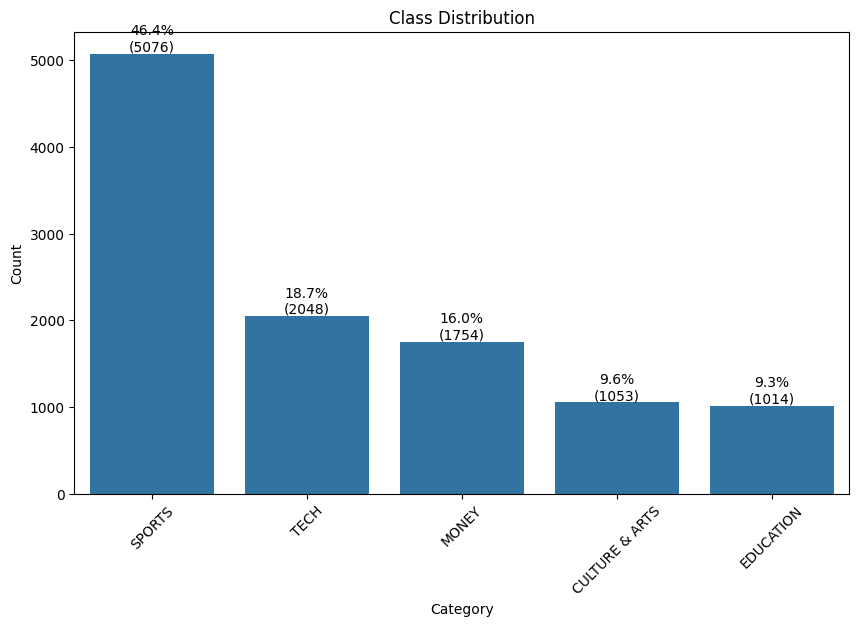

In [ ]:
# View class distribution of dataset

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    x='category',
    order=df['category'].value_counts().index
)

total = df.shape[0]

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total

    ax.annotate(f'{percentage:.1f}%\n({int(count)})',
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

Evidently, class distribution is poor for this dataset, could create a bias towards sports. Recall values must be monitored.

## Helper Functions for Preprocessing

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00


In [ ]:
import re
import nltk
import contractions

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk import pos_tag

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
def to_lower(text):
  ''' Convert text to lower case '''
  return text.lower()

In [ ]:
def remove_urls(text):
  ''' Remove any urls from text '''
  return re.sub(r'https?://\S+|www\.\S+', '', text)

In [ ]:
def expand_contractions(text):
  ''' Expand contractions to their full forms'''
  return contractions.fix(text)

In [ ]:
def remove_special_chars(text):
  ''' Remove non alpha characters '''
  return re.sub(r'[^a-zA-Z\s]', '', text)

In [ ]:
def tokenize(text):
  tokenizer = RegexpTokenizer(r"\w+")
  return tokenizer.tokenize(text)

In [ ]:
def get_wordnet_pos(tag):
  if tag.startswith('J'):
      return wordnet.ADJ
  elif tag.startswith('V'):
      return wordnet.VERB
  elif tag.startswith('N'):
      return wordnet.NOUN
  elif tag.startswith('R'):
      return wordnet.ADV
  else:
      return wordnet.NOUN

lemmatizer = WordNetLemmatizer()
def lemmatization(tokens):

  pos_tags = pos_tag(tokens)

  return [
      lemmatizer.lemmatize(word, get_wordnet_pos(tag))
      for word, tag in pos_tags
  ]

In [ ]:
stop_words = set(stopwords.words('english'))
print(stop_words)
def remove_stopwords(tokens):
  return [word for word in tokens if word not in stop_words]

{'needn', 'y', 'and', "he'd", "mustn't", 'did', 't', "doesn't", 'is', 'out', 'more', "haven't", 'can', 'this', 'against', "couldn't", 'whom', 'with', 'my', 'his', "i'll", 'as', 'very', 'm', "you'll", 'didn', 'been', 'itself', 'only', 'theirs', 'where', 'who', 'wouldn', 'because', 'had', 'once', 'during', 'above', 'doesn', "he'll", 'them', 'before', 'then', 'yourselves', 'down', 'd', 'than', 'himself', 's', 'herself', 'being', 'shouldn', "shan't", "mightn't", 'it', 'ma', 'having', 'are', 'couldn', 'she', 'ours', "that'll", 'not', 'themselves', 'we', "you're", 'its', 'any', 'isn', 'most', "you'd", "it's", 'am', 'their', "should've", 'a', 'these', 'have', 'until', 'no', 'if', "we've", "we're", 'in', 'other', "they'd", 'under', "i've", 'mustn', 'you', 'hers', 'all', "i'd", 'about', 'do', "she'll", 'again', 'the', 'few', "we'll", 'each', 'which', "she'd", "they've", "needn't", 'our', 'on', 'an', 'don', 'those', 'there', 'now', 'some', 'nor', "you've", "i'm", 'hasn', 'when', 'weren', 'mightn

In [ ]:
def text_cleaning_pipeline(text):
  text = remove_urls(text)
  text = expand_contractions(text)
  text = to_lower(text)
  text = remove_special_chars(text)
  tokens = tokenize(text)
  tokens = lemmatization(tokens)
  tokens = remove_stopwords(tokens)
  return " ".join(tokens)

## Preprocessing

In [ ]:
df["cleaned_headline"] = df["headline"].astype(str).apply(text_cleaning_pipeline)

In [ ]:
df.sample(10)

,headline,category,cleaned_headline
313,"A World Cup Bandwagoner's Guide To Mexico, Ame...",SPORTS,world cup bandwagoners guide mexico america team
8499,Chuck Pagano Letter: Colts Coach Writes Touchi...,SPORTS,chuck pagano letter colt coach write touch ope...
2519,Thousands Of NFL Players' Medical Records Stol...,SPORTS,thousand nfl player medical record steal skin ...
9679,Earning Below Minimum Wage Is Making Me A Lazy...,MONEY,earn minimum wage make lazy employee
6556,What Every Parent Needs to Know About Their Sc...,EDUCATION,every parent need know school
9584,College Tuition: 5 States Where Costs Are Rising,MONEY,college tuition state cost rise
2000,Brazil Judge Wants Answers From Ryan Lochte Ab...,SPORTS,brazil judge want answer ryan lochte alleged r...
4657,Watch Phil Mickelson Enjoy Life's Simpler Plea...,SPORTS,watch phil mickelson enjoy lifes simple pleasu...
4886,Google Airs Eye-Opening Ad On Trans Athletes B...,SPORTS,google air eyeopening ad trans athlete caitlyn...
10878,Amazon Whale Meat Ban Petition Calls For Retai...,TECH,amazon whale meat ban petition call retailer s...


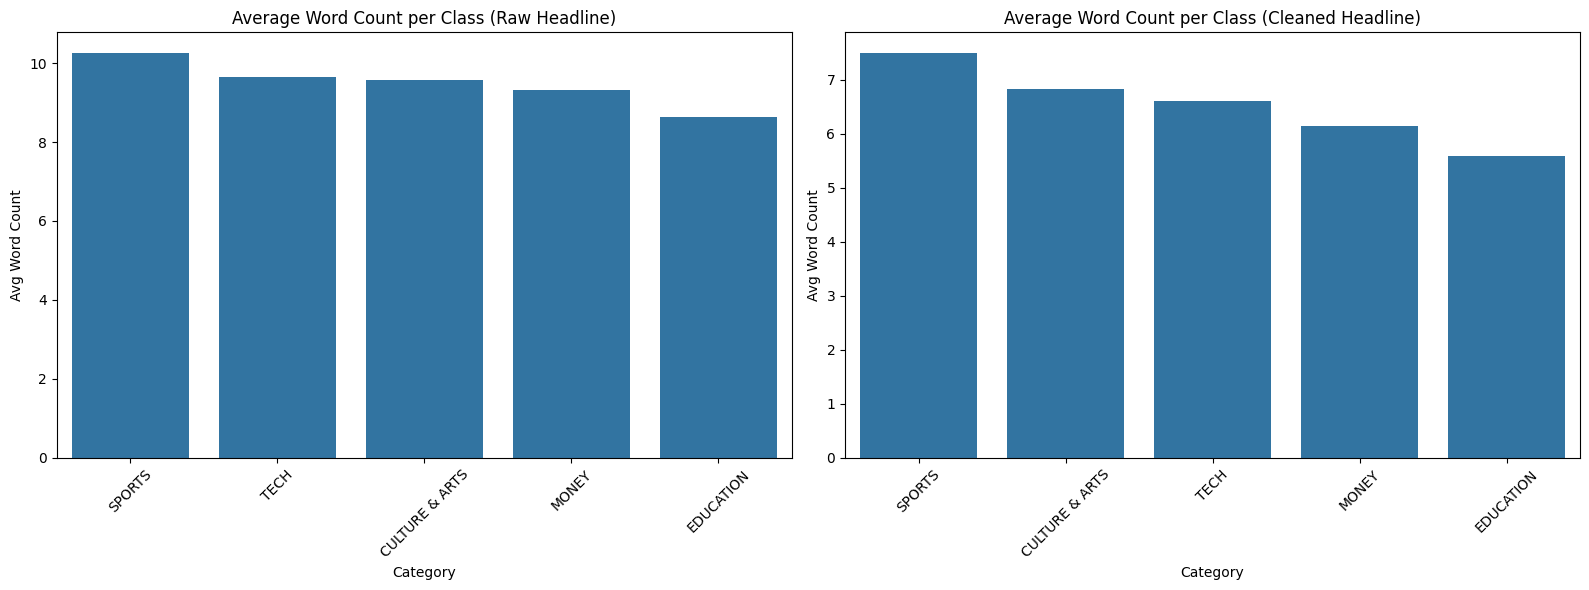

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# word count columns
df['headline_wc'] = df['headline'].apply(lambda x: len(x.split()))
df['cleaned_wc'] = df['cleaned_headline'].apply(lambda x: len(x.split()))

# group by category
raw_wc_avg = df.groupby('category')['headline_wc'].mean().sort_values(ascending=False)
clean_wc_avg = df.groupby('category')['cleaned_wc'].mean().sort_values(ascending=False)

# subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw headlines
sns.barplot(x=raw_wc_avg.index, y=raw_wc_avg.values, ax=axes[0])
axes[0].set_title("Average Word Count per Class (Raw Headline)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Avg Word Count")
axes[0].tick_params(axis='x', rotation=45)

# Cleaned headlines
sns.barplot(x=clean_wc_avg.index, y=clean_wc_avg.values, ax=axes[1])
axes[1].set_title("Average Word Count per Class (Cleaned Headline)")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Avg Word Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

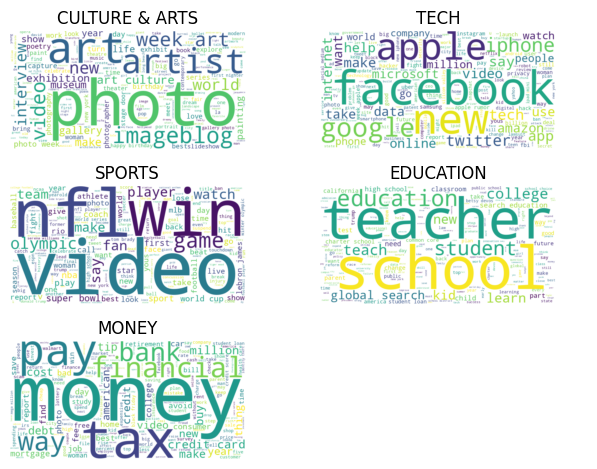

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(3, 2)
axes = axes.flatten()

categories = df["category"].unique()

for i, category in enumerate(categories):
  text = " ".join(df[df["category"] == category]["cleaned_headline"])

  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white'
  ).generate(text)

  axes[i].imshow(wordcloud, interpolation='bilinear')
  axes[i].axis("off")
  axes[i].set_title(category)

# remove empty subplot if 5 categories
for j in range(len(categories), len(axes)):
  axes[j].axis("off")

plt.tight_layout()
plt.show()

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X = df[["cleaned_headline","headline"]]
y = df["category"]

y = le.fit_transform(y)

X_train_both, X_test_both, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=25,
    stratify=y
)

X_train = X_train_both["cleaned_headline"]
X_test = X_test_both["cleaned_headline"]
print("Training data:", X_train.shape, y_train.shape)
print("Testing data:", X_test.shape, y_test.shape)

Training data: (8756,) (8756,)
Testing data: (2189,) (2189,)


Fit Keras Tokenizer

In [ ]:
# Create stratified validation set
X_train_final, X_val, y_train_final, y_val_final = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=25,
    stratify=y_train
)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Tokenize using keras preprocessing tokenizer

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)
vocab_size = len(tokenizer.word_index)
print("Unique vocabulary size:", vocab_size)

Unique vocabulary size: 10056


In [ ]:
train_sequences = tokenizer.texts_to_sequences(X_train_final)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Get padding length using 95 percentile
lengths = [len(seq) for seq in train_sequences]

max_len = int(np.percentile(lengths, 95))
print("Chosen max_len:", max_len)

# Add padding to the sequences

X_train_final = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
X_val_final = pad_sequences(val_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_final = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

Chosen max_len: 11


# Train and Evaluate Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

tf.keras.utils.set_random_seed(25)

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
num_classes = len(df['category'].unique())

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_final),
    y=y_train_final
)

class_weights = dict(enumerate(class_weights))

## Model 1: Simple RNN with trainable Embedding Layer

In [ ]:
model1 = Sequential([
  Embedding(vocab_size, 64),
  SimpleRNN(64, dropout=0.3, recurrent_dropout=0.1),
  Dense(num_classes, activation='softmax')
])

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='best_word2vec_lstm.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

lr_plateau = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, checkpoint, lr_plateau]

In [ ]:
model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model1.fit(
    X_train_final,
    y_train_final,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_final,y_val_final),
    shuffle=True,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4739 - loss: 1.3559 - val_accuracy: 0.6764 - val_loss: 0.9275 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7776 - loss: 0.7443 - val_accuracy: 0.7831 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8795 - loss: 0.4056 - val_accuracy: 0.7774 - val_loss: 0.7386 - learning_rate: 0.0010
Epoch 4/10
213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9156 - loss: 0.2775
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9233 - loss: 0.2546 - val_accuracy: 0.7734 - val_loss: 0.7942 - learning_rate: 0.0010
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9612 - loss: 0.1474 - val_accuracy: 0.7934 - val_loss: 0.7960 - learning_rate: 5.0000e-04


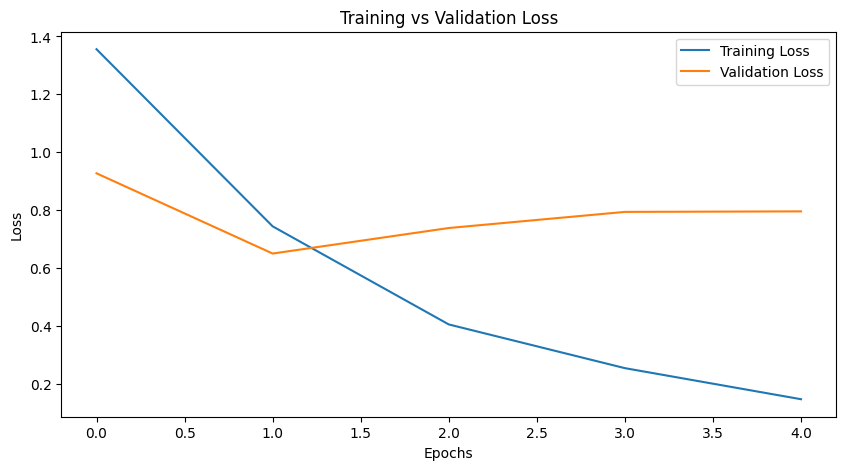

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred_probs = model1.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
                precision    recall  f1-score   support

CULTURE & ARTS       0.54      0.71      0.61       211
     EDUCATION       0.64      0.68      0.66       203
         MONEY       0.77      0.72      0.75       351
        SPORTS       0.92      0.87      0.89      1015
          TECH       0.74      0.74      0.74       409

      accuracy                           0.79      2189
     macro avg       0.72      0.75      0.73      2189
  weighted avg       0.80      0.79      0.79      2189



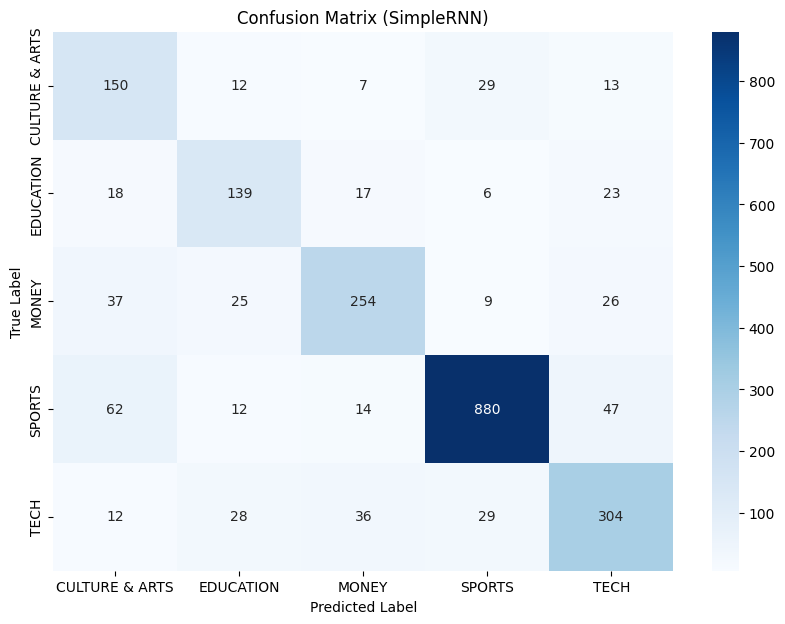

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (SimpleRNN)")
plt.show()

In [ ]:
wrong_idx = np.where(y_pred != y_test)[0]
print("Some Wrong Predictions:\n")

for i in wrong_idx[:10]:
  print(f"Actual Text: {X_test_both.iloc[i]['headline']}")
  print(f"Cleaned Text: {X_test_both.iloc[i]['cleaned_headline']}")
  print(f"True Label: {le.classes_[y_test[i]]}")
  print(f"Predicted: {le.classes_[y_pred[i]]}")
  print("-" * 50)

Some Wrong Predictions:

Actual Text: Here's What New York City's Boroughs Should Look Like If They Were Redrawn Today
Cleaned Text: new york city borough look like redrawn today
True Label: TECH
Predicted: MONEY
--------------------------------------------------
Actual Text: #TwitpicYourDunkContestReaction Was Way More Impressive Than Actual Dunk Contest (PHOTOS)
Cleaned Text: twitpicyourdunkcontestreaction way impressive actual dunk contest photo
True Label: SPORTS
Predicted: CULTURE & ARTS
--------------------------------------------------
Actual Text: Blueseed Raising Money To Park Ship Full of Startups Near SF
Cleaned Text: blueseed raise money park ship full startup near sf
True Label: TECH
Predicted: MONEY
--------------------------------------------------
Actual Text: This Is The Soccer-Themed 'Ferris Bueller's Day Off' Parody We Deserve
Cleaned Text: soccerthemed ferris buellers day parody deserve
True Label: SPORTS
Predicted: CULTURE & ARTS
-----------------------------------

## Model 2: LSTM with trainable Embedding Layer

In [ ]:
model2 = Sequential([
    Embedding(vocab_size, 64),
    LSTM(64, dropout=0.3, recurrent_dropout=0.1),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='best_word2vec_lstm.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

lr_plateau = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, checkpoint, lr_plateau]

In [ ]:
model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history2 = model2.fit(
    X_train_final,
    y_train_final,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_final,y_val_final),
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.5468 - loss: 1.1215 - val_accuracy: 0.6027 - val_loss: 0.8978 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.7346 - loss: 0.6462 - val_accuracy: 0.7974 - val_loss: 0.6124 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.8905 - loss: 0.3108 - val_accuracy: 0.8014 - val_loss: 0.6048 - learning_rate: 0.0010
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9465 - loss: 0.1697 - val_accuracy: 0.8145 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9687 - loss: 0.1138
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9690 - loss: 0.1100 - val_accuracy: 0.8139 - val_loss: 0.6628 - learning_rate: 0.0010
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.9842 - los

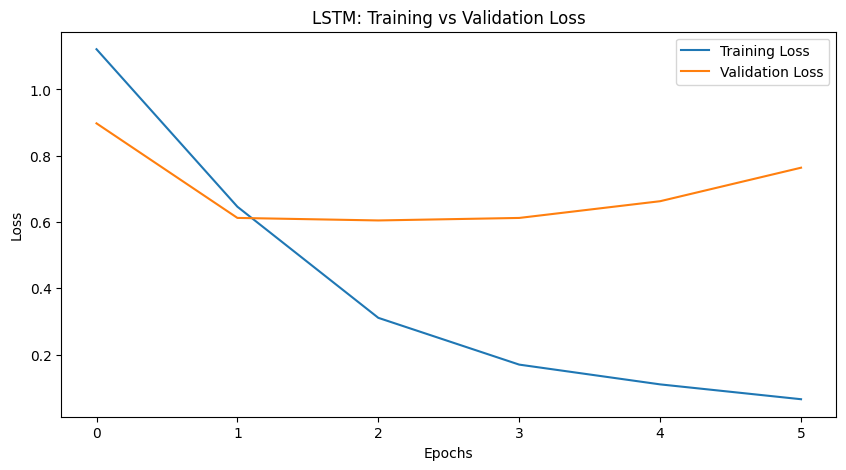

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title('LSTM: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred_probs = model2.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
                precision    recall  f1-score   support

CULTURE & ARTS       0.58      0.63      0.60       211
     EDUCATION       0.61      0.67      0.64       203
         MONEY       0.81      0.71      0.76       351
        SPORTS       0.93      0.89      0.91      1015
          TECH       0.75      0.83      0.78       409

      accuracy                           0.80      2189
     macro avg       0.73      0.75      0.74      2189
  weighted avg       0.81      0.80      0.81      2189



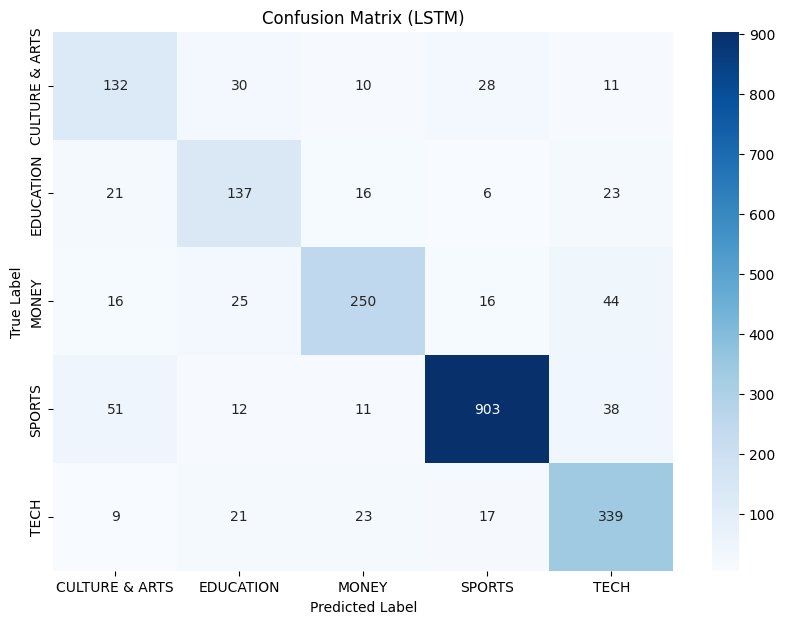

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (LSTM)")
plt.show()

In [ ]:
wrong_idx = np.where(y_pred != y_test)[0]
print("Some Wrong Predictions:\n")

for i in wrong_idx[:10]:
  print(f"Actual Text: {X_test_both.iloc[i]['headline']}")
  print(f"Cleaned Text: {X_test_both.iloc[i]['cleaned_headline']}")
  print(f"True Label: {le.classes_[y_test[i]]}")
  print(f"Predicted: {le.classes_[y_pred[i]]}")
  print("-" * 50)

Some Wrong Predictions:

Actual Text: Here's What New York City's Boroughs Should Look Like If They Were Redrawn Today
Cleaned Text: new york city borough look like redrawn today
True Label: TECH
Predicted: SPORTS
--------------------------------------------------
Actual Text: Steelers-Patriots Live Game Updates
Cleaned Text: steelerspatriots live game update
True Label: SPORTS
Predicted: TECH
--------------------------------------------------
Actual Text: #TwitpicYourDunkContestReaction Was Way More Impressive Than Actual Dunk Contest (PHOTOS)
Cleaned Text: twitpicyourdunkcontestreaction way impressive actual dunk contest photo
True Label: SPORTS
Predicted: CULTURE & ARTS
--------------------------------------------------
Actual Text: Blueseed Raising Money To Park Ship Full of Startups Near SF
Cleaned Text: blueseed raise money park ship full startup near sf
True Label: TECH
Predicted: MONEY
--------------------------------------------------
Actual Text: Lee Chong Wei, Malaysian Badm

## Model 3: LSTM with Word2Vec Embeddings

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.9 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api
import numpy as np

embedding_model = api.load('word2vec-google-news-300')
embedding_dim = 300

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_vector = embedding_model[word]
        embedding_matrix[i] = embedding_vector
    else:
        pass

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
model3 = Sequential([
    Embedding(
      input_dim=vocab_size,
      output_dim=embedding_dim,
      weights=[embedding_matrix],
      trainable=False
    ),
    LSTM(64, dropout=0.3, recurrent_dropout=0.1),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,017,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,017,100 (11.51 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,017,100 (11.51 MB)

In [ ]:
model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='best_word2vec_lstm.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

lr_plateau = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, checkpoint, lr_plateau]

In [ ]:
history3 = model3.fit(
    X_train_final,
    y_train_final,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_final,y_val_final),
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 101ms/step - accuracy: 0.7234 - loss: 0.7781 - val_accuracy: 0.8168 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - accuracy: 0.8288 - loss: 0.4943 - val_accuracy: 0.8282 - val_loss: 0.5075 - learning_rate: 0.0010
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.8465 - loss: 0.4453 - val_accuracy: 0.8305 - val_loss: 0.4984 - learning_rate: 0.0010
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step - accuracy: 0.8567 - loss: 0.4199 - val_accuracy: 0.8328 - val_loss: 0.4885 - learning_rate: 0.0010
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.8617 - loss: 0.4076 - val_accuracy: 0.8362 - val_loss: 0.4681 - learning_rate: 0.0010
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8692 - loss: 0.3875 - val_accuracy: 0.8385 - val_loss: 0.4681 - learning_rate: 0.0010
Epoch 7/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8689 - 

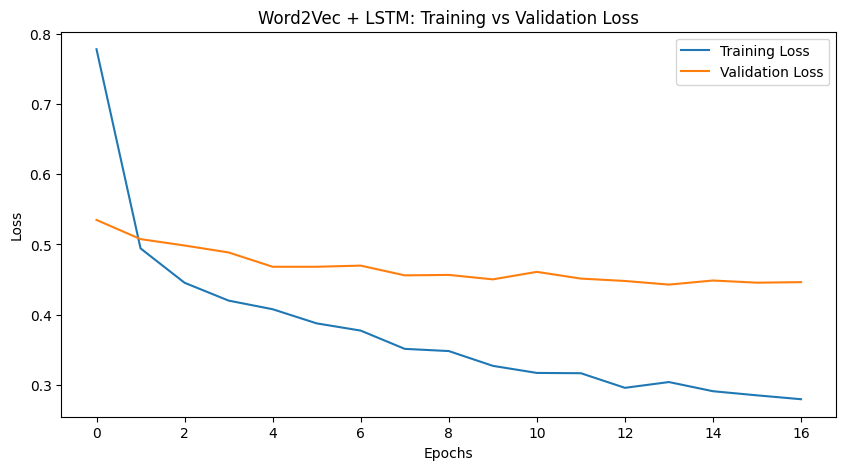

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')

plt.title('Word2Vec + LSTM: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
y_pred_probs = model3.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
                precision    recall  f1-score   support

CULTURE & ARTS       0.78      0.65      0.71       211
     EDUCATION       0.79      0.74      0.77       203
         MONEY       0.84      0.79      0.82       351
        SPORTS       0.90      0.95      0.92      1015
          TECH       0.82      0.84      0.83       409

      accuracy                           0.86      2189
     macro avg       0.83      0.79      0.81      2189
  weighted avg       0.85      0.86      0.85      2189



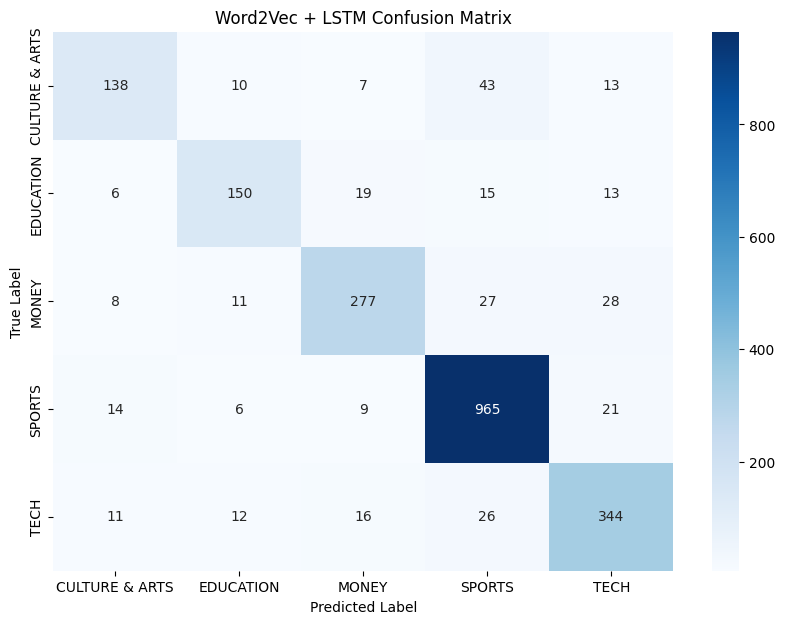

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Word2Vec + LSTM Confusion Matrix")
plt.show()

In [ ]:
wrong_idx = np.where(y_pred != y_test)[0]
print("Some Wrong Predictions:\n")

for i in wrong_idx[:10]:
  print(f"Actual Text: {X_test_both.iloc[i]['headline']}")
  print(f"Cleaned Text: {X_test_both.iloc[i]['cleaned_headline']}")
  print(f"True Label: {le.classes_[y_test[i]]}")
  print(f"Predicted: {le.classes_[y_pred[i]]}")
  print("-" * 50)

Some Wrong Predictions:

Actual Text: Here's What New York City's Boroughs Should Look Like If They Were Redrawn Today
Cleaned Text: new york city borough look like redrawn today
True Label: TECH
Predicted: SPORTS
--------------------------------------------------
Actual Text: Lee Chong Wei, Malaysian Badminton Player, Wants Fans To Facebook Him To Get Wedding Invites
Cleaned Text: lee chong wei malaysian badminton player want fan facebook get wedding invite
True Label: TECH
Predicted: SPORTS
--------------------------------------------------
Actual Text: Uprade Your Phone For Less!
Cleaned Text: uprade phone less
True Label: MONEY
Predicted: TECH
--------------------------------------------------
Actual Text: Underearners Anonymous Helps The Perpetually Underpaid
Cleaned Text: underearners anonymous help perpetually underpaid
True Label: MONEY
Predicted: TECH
--------------------------------------------------
Actual Text: Teach For America’s Houston T-shirt Sale
Cleaned Text: teach am

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict(text):
  cleaned = text_cleaning_pipeline(text)
  seq = tokenizer.texts_to_sequences([cleaned])
  padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

  pred = model3.predict(padded)
  label = le.inverse_transform([np.argmax(pred)])

  return label[0]

gr.Interface(
    fn=predict,
    inputs="text",
    outputs="text",
    title="NLP Classifier"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://463f226ba51c51b66b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
